In [ ]:
!pip install pillow matplotlib numpy

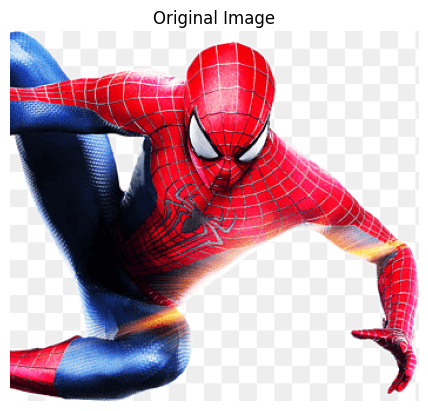

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and display image
img = Image.open('/content/input.png').convert('RGB')
img_np = np.array(img)

plt.imshow(img_np)
plt.title("Original Image")
plt.axis('off')
plt.show()

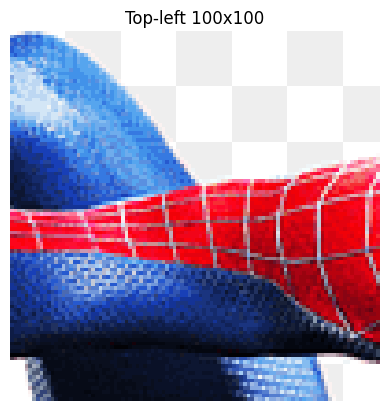

In [ ]:
# 2. Top-left 100x100 pixels
top_left = img_np[:100, :100]

plt.imshow(top_left)
plt.title("Top-left 100x100")
plt.axis('off')
plt.show()

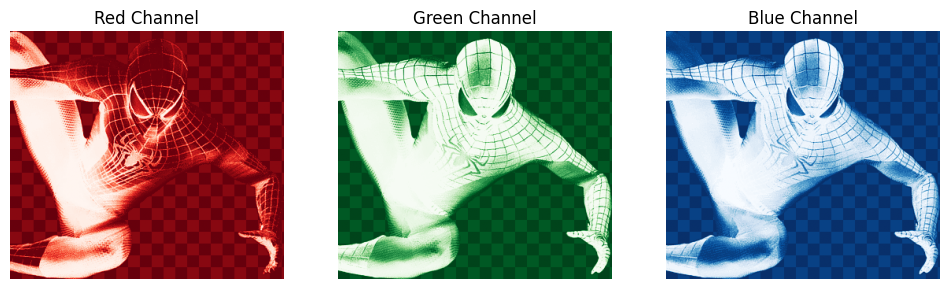

In [ ]:
# 3. Separate RGB channels
R = img_np[:, :, 0]
G = img_np[:, :, 1]
B = img_np[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis('off')

plt.show()

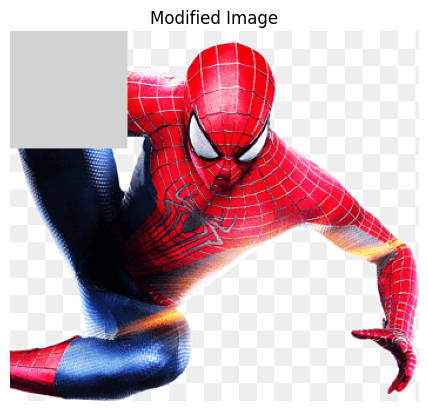

In [ ]:
# 4. Modify top-left 100x100 to 210
modified = img_np.copy()
modified[:100, :100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis('off')
plt.show()

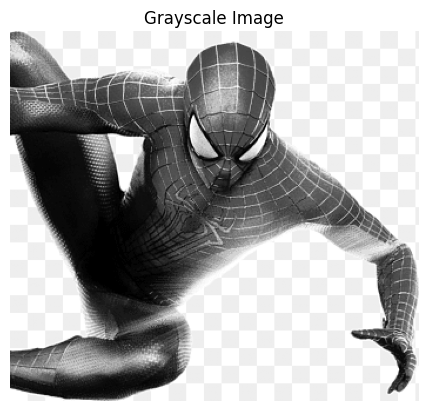

In [ ]:
# Load grayscale image
gray_img = Image.open('/content/input.png').convert('L')
gray_np = np.array(gray_img)

plt.imshow(gray_np, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

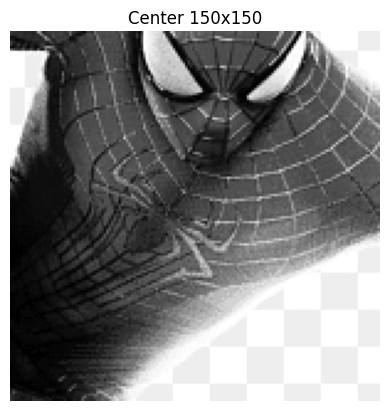

In [ ]:
# 2. Middle 150x150 crop
h, w = gray_np.shape
center_crop = gray_np[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center_crop, cmap='gray')
plt.title("Center 150x150")
plt.axis('off')
plt.show()

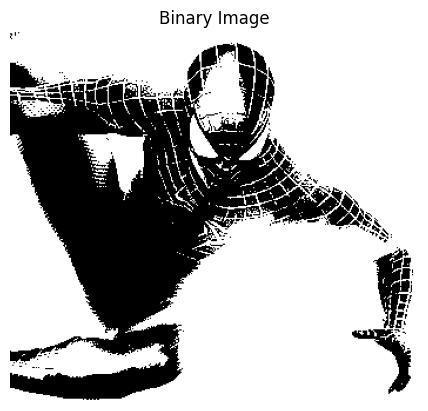

In [ ]:
# 3. Thresholding
binary = np.where(gray_np < 100, 0, 255)

plt.imshow(binary, cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

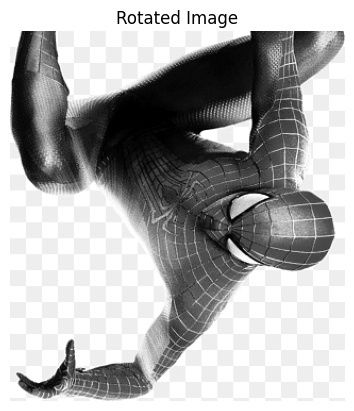

In [ ]:
# 4. Rotate 90° clockwise
rotated = np.rot90(gray_np, k=-1)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated Image")
plt.axis('off')
plt.show()

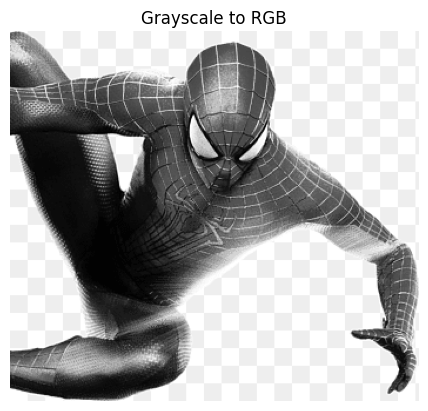

In [ ]:
# 5. Convert grayscale to RGB
rgb = np.stack((gray_np,)*3, axis=-1)

plt.imshow(rgb)
plt.title("Grayscale to RGB")
plt.axis('off')
plt.show()

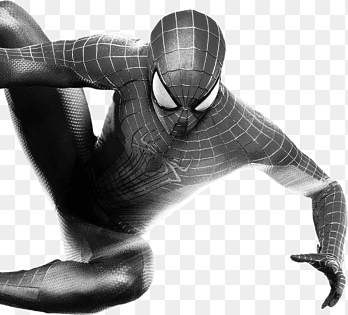

In [ ]:
img = Image.open('/content/input.png').convert('L')
img_np = np.array(img, dtype=np.float64)
display(img)

# 1. Standardize (center data)
mean = np.mean(img_np, axis=0)
centered = img_np - mean

# Covariance matrix
cov = np.cov(centered, rowvar=False)

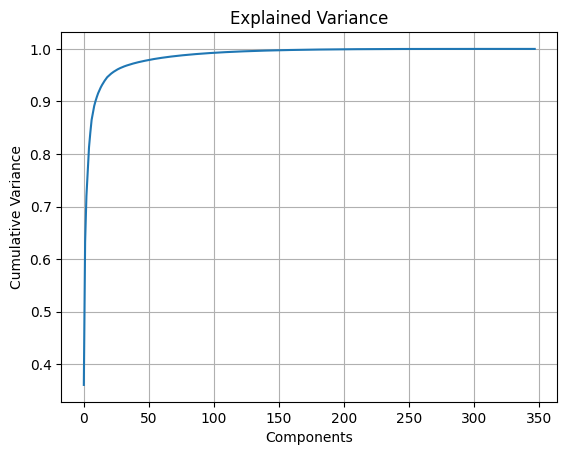

In [ ]:
# 2. Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Explained variance
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.plot(cumulative_variance)
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.title("Explained Variance")
plt.grid()
plt.show()

In [ ]:
def reconstruct(k):
    eigvecs_k = eigenvectors[:, :k]
    compressed = np.dot(centered, eigvecs_k)
    reconstructed = np.dot(compressed, eigvecs_k.T) + mean
    return reconstructed

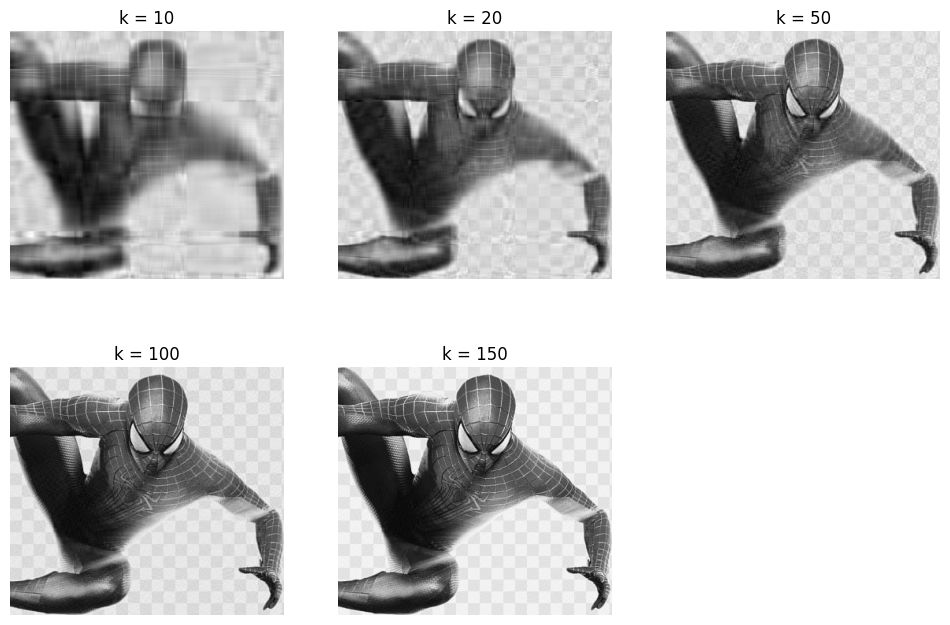

In [ ]:
ks = [10, 20, 50, 100, 150]

plt.figure(figsize=(12,8))

for i, k in enumerate(ks):
    rec = reconstruct(k)
    plt.subplot(2,3,i+1)
    plt.imshow(rec, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.show()